In [ ]:
# Only for Google Colab

# Set the runtime session to a GPU session first!
# Clone the repository  (TODO: final repository name)
!git clone https://github.com/RobvanGastel/air-hockey-world-model.git

# Change directory to the cloned repository
%cd air-hockey-world-model

# Install dependencies and the wm package
!pip install -e .

# Multiplayer World Models from Pixels and Keys

In this notebook, I walk through how a multiplayer interactive world model works, following MIRA (Hu et al., 2026) on a two-player air hockey game. A world model learns to simulate a game from pixels and actions alone. Given a few frames of context and the keys each player presses, it generates the next frames for both players. Once trained, the game can be played inside the model, without the game engine.

The model has two parts, which are also the two halves of this notebook:

1. **A codec** that compresses each frame into a small latent. It uses frozen DINOv3 (Siméoni et al., 2025) features, following representation autoencoders (Zheng et al., 2025), so the latents describe *what is in the frame* rather than raw pixels.
2. **A diffusion transformer** that predicts the next latent from the previous latents and both players' keys, trained with flow matching (Lipman et al., 2023).

Because the game simulator is ours, we can check what the model gets right against the true game state, which is the last part of the notebook.

## Setup

The notebook needs three sets of trained weights: the agents that play the game, the codec and the world model. Set the paths below to where you saved them.

In [18]:
%matplotlib inline

import random
import subprocess
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib.pyplot as plt
from einops import rearrange
from IPython.display import Image as GIF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: replace with the download location of the released weights, explained in the README.md
AGENTS = "runs/ppo_*/*_best.pt"          # PPO agents that play the matches
WORLD_MODEL = "runs/wm/world_model.pt"  # also loads the codec named in its config
DATA = Path("data/notebook")              # a few matches collected below
device

device(type='cuda')

## The game

The game is a two-player air hockey table. Each player steers a mallet with the W/A/S/D keys and tries to hit the puck into the other player's goal. Every frame is rendered twice, once from each player's side of the table, so each player sees its own goal at the bottom. These two views are what the world model has to generate.

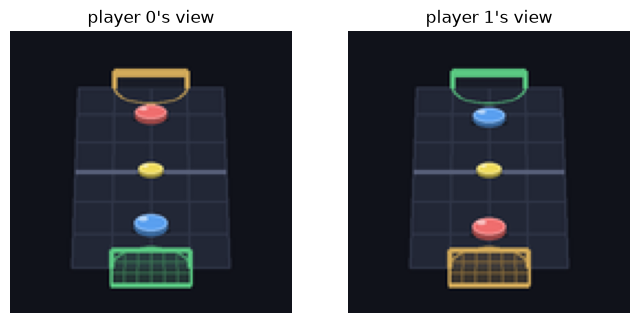

In [19]:
from wm.env.arena import ArenaConfig, ArenaOracle
from wm.env.render_iso import render_iso

cfg = ArenaConfig(n_mallets=2, frame_size=128)
oracle = ArenaOracle(cfg, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for player, ax in enumerate(axes):
    ax.imshow(render_iso(oracle, agent_idx=player))
    ax.set_title(f"player {player}'s view")
    ax.axis("off")
plt.show()

A key does not move the mallet directly. It pushes the mallet with a constant force, so holding a key makes the mallet speed up, and releasing it lets the mallet glide. Because the table's long axis runs vertically on screen, W and S push the mallet sideways and A and D push it up and down. The world model never sees these rules: it has to learn them from the recorded frames and keys.

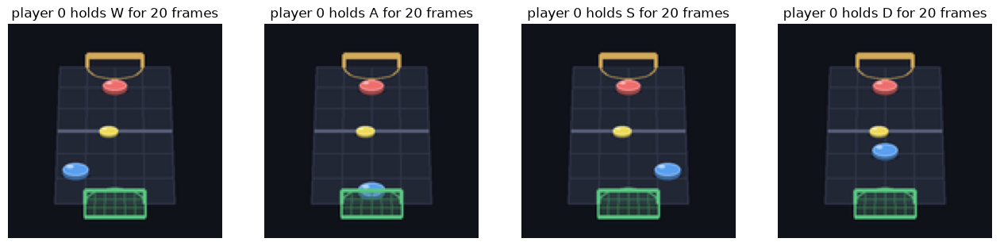

In [20]:
from tools.agent.collect_matches import wasd_to_action

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key in zip(axes, "wasd"):
    oracle = ArenaOracle(cfg, seed=0)
    action = wasd_to_action(tuple(int(key == k) for k in "wasd"))
    for _ in range(20):  # hold the key for 20 frames (1/3 s), player 1 stays still
        oracle.step([tuple(action), (0.0, 0.0)])
    ax.imshow(render_iso(oracle, agent_idx=0))
    ax.set_title(f"player 0 holds {key.upper()} for 20 frames")
    ax.axis("off")
plt.show()

## Collecting data

The matches are played by PPO (Schulman et al., 2017) agents. Two choices in the data turned out to matter a lot for whether the world model listens to the keys:

- **Every action is played as keys.** The agents were trained with continuous thrust, but the world model only sees W/A/S/D. Each action is therefore snapped to full thrust on the keys it is recorded as (`--wasd-actions`), so "D" always means the same push.
- **Some moves are random.** An agent's next key is mostly predictable from the frames, so a model can predict the agent without reading the keys. With `--random-frac 0.3`, each player spends about 30% of the time holding a random key combination that only the keys can explain.

Here I collect two matches to look at.

In [21]:
if not (DATA / "manifest_0000.jsonl").exists():
    subprocess.run(
        ["python", "-m", "tools.agent.collect_matches", "--checkpoints-glob", AGENTS, "--num-matches", "2",
         "--wasd-actions", "--random-frac", "0.3", "--out-dir", str(DATA)],
        check=True,
    )

from wm.data.dataset import create_multiplayer_loader

N_CONTEXT, N_ROLLOUT = 39, 30  # context frames, then latent steps to generate (2 frames each)
random.seed(0)
loader = create_multiplayer_loader(
    DATA, clip_len=N_CONTEXT + 2 * N_ROLLOUT, batch_size=2,
    actions_config=SimpleNamespace(valid_keys=["w", "a", "s", "d"]), num_workers=0, seed=0,
)
batch = next(iter(loader))
# rows are [game 0 player 0, game 0 player 1, game 1 player 0, ...]
batch.video.shape, batch.actions.key_presses.shape

(torch.Size([4, 99, 3, 160, 128]), torch.Size([4, 98, 4]))

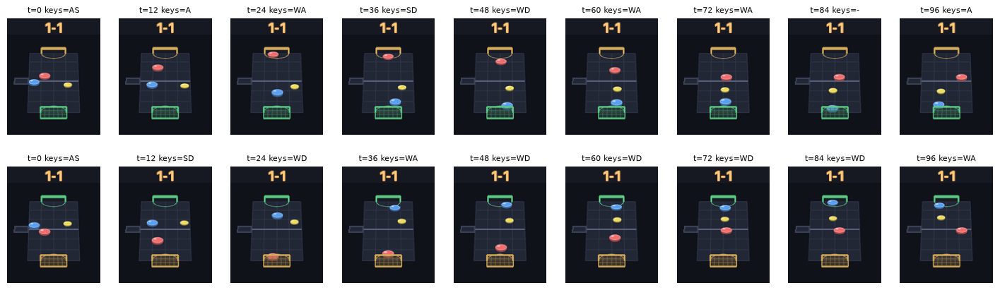

In [22]:
frames = range(0, batch.video.shape[1], 12)
fig, axes = plt.subplots(2, len(frames), figsize=(2 * len(frames), 5))
for player in range(2):
    for ax, t in zip(axes[player], frames):
        ax.imshow(batch.video[player, t].permute(1, 2, 0))
        keys = "".join(k.upper() for k, on in zip("wasd", batch.actions.key_presses[player, t]) if on)
        ax.set_title(f"t={t} keys={keys or '-'}", fontsize=8)
        ax.axis("off")
plt.show()

## The codec: frames to latents

Diffusion directly on pixels is expensive and spends most of its capacity on details that do not matter for the game. Instead, every frame is first compressed into a latent. Following representation autoencoders (Zheng et al., 2025), the encoder is a frozen DINOv3 ViT-S/16. DINOv3's patch features already separate the objects in an image, which the PCA below shows: the puck, the mallets and the table get different colours without any training on this game.

On top of DINOv3, a strided convolution compresses two consecutive frames of 10×8 patch features into one 5×4×32 latent, and a ViT decoder learns to turn latents back into frames. Only the convolution and the decoder are trained.

In [23]:
from wm.data.batch import VideoActionBatch
from wm.world_model.multi_wrapper_world_model import MultiWrapperWorldModel

model = MultiWrapperWorldModel.load_from_checkpoint(WORLD_MODEL, device=device).eval()
swm = model.single_world_model
codec = swm.codec

with torch.no_grad():
    clip = VideoActionBatch(video=batch.video[:1, :8].clone().to(device))  # player 0, 8 frames
    codec.preprocess_batch(clip)  # to [0, 1], resized to the codec's resolution
    _, encoded = codec.encode(clip.video, trim_video=False)
    reconstruction = codec.decode(encoded.z) * 0.5 + 0.5

print("frames:      ", tuple(clip.video.shape))
print("DINOv3 patch:", tuple(encoded.dino_features[-1].shape))
print("latents:     ", tuple(encoded.z.shape))

frames:       (1, 8, 3, 160, 128)
DINOv3 patch: (1, 8, 384, 10, 8)
latents:      (1, 4, 32, 5, 4)


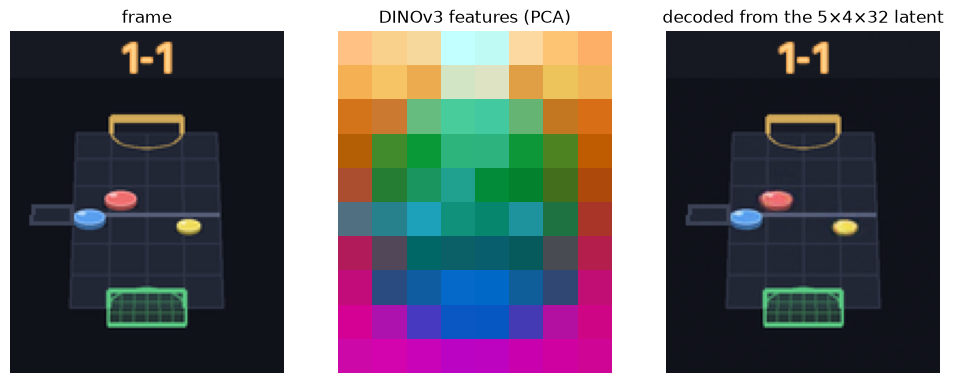

In [24]:
# PCA of the DINOv3 patch features: the three main directions as RGB
features = encoded.dino_features[-1][0, 0]  # (C, h, w) of the first frame
flat = rearrange(features, "c h w -> (h w) c").float()
flat = flat - flat.mean(0)
_, _, v = torch.linalg.svd(flat, full_matrices=False)
pca = flat @ v[:3].T
pca = (pca - pca.min(0).values) / (pca.max(0).values - pca.min(0).values)
pca = rearrange(pca, "(h w) c -> h w c", h=features.shape[1]).cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, img, title in zip(
    axes,
    [clip.video[0, 0].permute(1, 2, 0).cpu(), pca, reconstruction[0, 0].permute(1, 2, 0).clamp(0, 1).cpu()],
    ["frame", "DINOv3 features (PCA)", "decoded from the 5×4×32 latent"],
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.show()

## The world model: predicting the next latent

The world model is a transformer that alternates attention within a frame (over the latent's 5×4 positions) and attention across time (over the previous frames). Attention across time is causal, so a frame only sees the past.

It is trained with flow matching (Lipman et al., 2023). For a clean latent $z_1$ and Gaussian noise $z_0$, the model sees a mix $z_\tau = \tau z_1 + (1 - \tau) z_0$ and learns to predict the direction $v = z_1 - z_0$ that removes the noise:

$$\mathcal{L} = \mathbb{E}_{\tau, z_0}\left\| v_\theta(z_\tau, \tau, z_{<t}, a_t) - (z_1 - z_0) \right\|^2$$

Each frame gets its own noise level $\tau$, and the model is conditioned on the clean previous latents $z_{<t}$, so the training matches how it is used: at inference time, the past is always clean and only the next frame is noisy. Generating a frame starts from pure noise and takes 10 small steps along $v_\theta$. The new latent is then added to the context, and the model moves on to the next frame.

### Actions and time

The keys enter every layer through adaptive layer norm: each player's keys are embedded and added to the noise-level embedding, which then scales and shifts the activations. What matters most is *which* keys condition *which* latent. One latent covers two frames, so each latent must see exactly the two key presses that produced its two frames. An earlier version of this code fed one key press per latent from about half its own time, and the model learned to ignore its keys entirely.

In [25]:
atd = swm.action_temporal_downsampling
offset = atd - 1
print(f"context: {swm.n_context_frames} frames = {swm.n_context_latents} latents")
print(f"frames per latent: {swm.temporal_downsampling}, key presses per latent: {atd}")
for j in (1, 2, swm.n_context_latents):
    first = offset + (j - 1) * atd
    print(f"latent {j:2d} (frames {2 * j}, {2 * j + 1}) <- key presses {first}, {first + 1}")

n_params = lambda m: sum(p.numel() for p in m.parameters()) / 1e6
print(f"\ncodec {n_params(codec):.1f}M (frozen), diffusion transformer {n_params(swm.world_model):.1f}M")

context: 39 frames = 19 latents
frames per latent: 2, key presses per latent: 2
latent  1 (frames 2, 3) <- key presses 1, 2
latent  2 (frames 4, 5) <- key presses 3, 4
latent 19 (frames 38, 39) <- key presses 37, 38

codec 46.0M (frozen), diffusion transformer 36.0M


## Two players in one frame

MIRA handles several players by tiling their views into one frame. Each player's view is encoded separately, and the latents are stacked on top of each other, so the transformer generates both views as one image. Attention within a frame can then look across both views, which is what keeps them consistent: when the puck enters a goal, both views show the goal and both scoreboards update. Each player's keys get their own embedding and are combined before conditioning.

In [26]:
with torch.no_grad():
    context = VideoActionBatch(video=batch.video[:2, :N_CONTEXT].clone().to(device))  # game 0, both players
    swm.codec.preprocess_batch(context)
    z = swm.encode_video(context)  # (players, t, h, w, c)
tiled = rearrange(z, "(b p) t h w c -> b t (p h) w c", p=model.n_players)
print("per player:", tuple(z.shape), "-> tiled:", tuple(tiled.shape))

per player: (2, 19, 5, 4, 32) -> tiled: (1, 19, 10, 4, 32)


## Rolling out the world model

Now the model generates one second of play after the 39 real context frames. I roll out the same two games twice: once with the keys that were really pressed, and once with the keys of the other game. In the GIF, the columns are the real game, the rollout with the true keys and the rollout with the other game's keys. The border turns red once the model is generating.

In [27]:
from PIL import Image, ImageDraw

def to_uint8(video):
    """(T, C, H, W) in [0, 1] -> (T, H, W, C) uint8 frames."""
    return (video * 255).clamp(0, 255).to(torch.uint8).permute(0, 2, 3, 1).cpu().numpy()

def save_grid_gif(columns, titles, path, upscale=2, ms=50):
    """columns[c][p] = (T, H, W, C) uint8 frames -> GIF with one column per video, one row per player."""
    n_frames, h, w = columns[0][0].shape[:3]
    h, w, pad, header = h * upscale, w * upscale, 4, 16
    frames = []
    for t in range(n_frames):
        img = Image.new("RGB", (len(columns) * (w + pad) + pad, header + len(columns[0]) * (h + pad) + pad), (10, 11, 15))
        draw = ImageDraw.Draw(img)
        for c, (column, title) in enumerate(zip(columns, titles)):
            x = pad + c * (w + pad)
            draw.text((x + 2, 2), title, fill=(230, 230, 230))
            for p, video in enumerate(column):
                img.paste(Image.fromarray(video[t]).resize((w, h), Image.NEAREST), (x, header + pad + p * (h + pad)))
        frames.append(img)
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=ms, loop=0)

sampling = SimpleNamespace(n_diffusion_steps=10, noise_level=0.2, schedule_type="linear_quadratic")

def rollout(actions, seed=0):
    torch.manual_seed(seed)  # same noise for every rollout, so only the keys differ
    with torch.no_grad():
        out = model.inference(VideoActionBatch(video=batch.video.clone(), actions=actions),
                              config=sampling, progress_bar=False)
        return out.preprocessed_batch.video, swm.decode_to_video(out.z_t)

swapped = batch.actions.slice_time(None, None)
games = rearrange(batch.actions.key_presses, "(b p) t k -> b p t k", p=model.n_players)
swapped.key_presses = rearrange(games.roll(1, dims=0), "b p t k -> (b p) t k")

real, generated = rollout(batch.actions)
_, generated_swapped = rollout(swapped)
n_frames = generated.shape[1]
real = real[:, :n_frames]

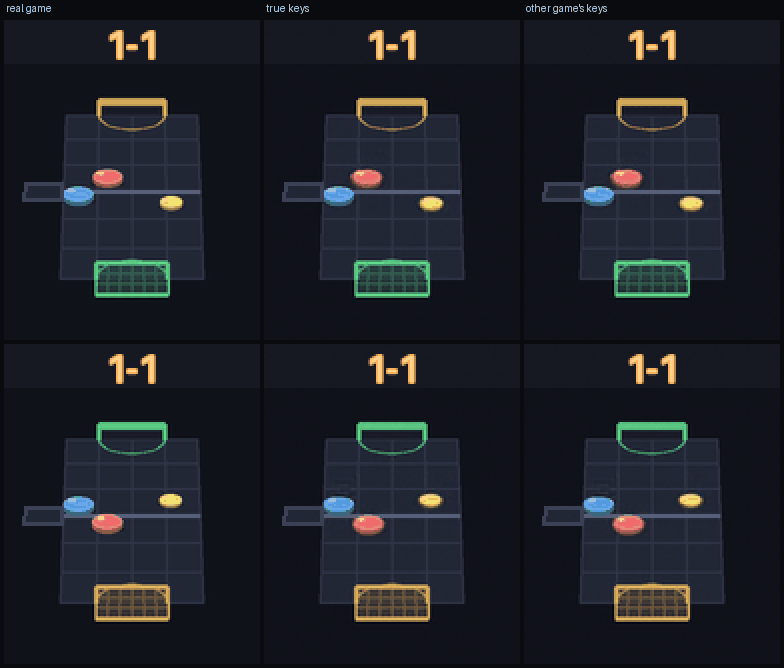

In [28]:
per_game = lambda v: rearrange(v, "(b p) t c h w -> b p t c h w", p=model.n_players)
videos = [per_game(real), per_game(generated), per_game(generated_swapped)]
columns = [[to_uint8(v[0, p]) for p in range(model.n_players)] for v in videos]
save_grid_gif(columns, ["real game", "true keys", "other game's keys"], DATA / "rollout.gif")
GIF(filename=DATA / "rollout.gif")

## Did the model follow the keys?

Looking at rollouts is useful, but it does not say how close the model is. Because the puck and each mallet have a fixed colour, I can find their positions in every generated frame and compare them with the real game. The interesting comparison is each player's own mallet: with the true keys it should follow the real mallet, with the other game's keys it should not.

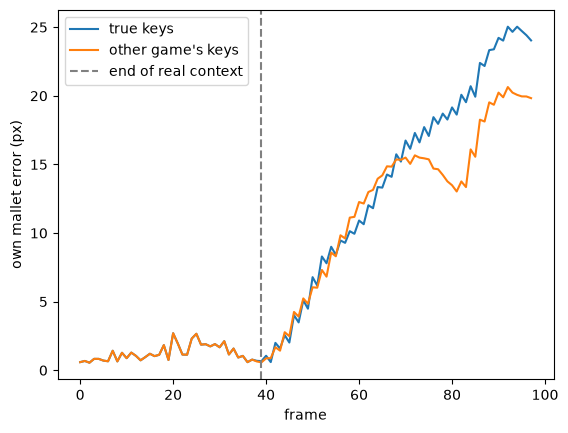

In [29]:
from tools.evaluation.evaluate_wm import OWN_MALLET_RGB, puck_centroid

def own_mallet_error(video):
    errors = []
    for player, colour in enumerate(OWN_MALLET_RGB):
        pred, _ = puck_centroid(video[player::2].float(), color=colour)
        true, _ = puck_centroid(real[player::2].float(), color=colour)
        errors.append((pred - true).norm(dim=-1))
    return torch.cat(errors).mean(0).cpu()  # mean over games and players, per frame

t = np.arange(n_frames)
plt.plot(t, own_mallet_error(generated), label="true keys")
plt.plot(t, own_mallet_error(generated_swapped), label="other game's keys")
plt.axvline(N_CONTEXT, color="gray", linestyle="--", label="end of real context")
plt.xlabel("frame")
plt.ylabel("own mallet error (px)")
plt.legend()
plt.show()

## Playing against the world model

The model can also play a player itself. During training, each player's actions are replaced by a learned "unknown" token 10% of the time (action dropout, as in MIRA). On those steps the model has to predict what that player does from the frames alone, so it learns to play like the agents in the data. If the opponent's actions are always unknown, the model plays the opponent, and you can play against it.

Generating one step at a time works like the rollout above. The model keeps the last 20 latents; each step drops the oldest, adds a noisy new one, and denoises it given the keys. The attention over earlier latents is cached, so a step only computes the new latent. You control player 0. Its keys enter as usual, two key rows per latent; player 1's rows are always dropped.

In [47]:
from wm.world_model.action_configs import ActionTensors

# The table's long axis runs vertically on screen, so the game's own keys are rotated (see "The game"):
# "d" moves your mallet up, "w" left, "a" down and "s" right. Map the screen directions you press to them.
SCREEN_TO_GAME = {"w": "d", "a": "w", "s": "a", "d": "s"}
DROP = torch.tensor([False, True], device=device)  # rows (player 0, player 1): player 1's actions are unknown
# One denoising step: the model was trained with PSD self-distillation, which makes a single step about as
# accurate as ten (own-mallet and puck error within ~10%) and ten times faster. noise_level=None also skips the
# extra pass that re-noises the finished latent for the cache.
play_sampling = SimpleNamespace(n_diffusion_steps=4, noise_level=None, schedule_type="linear_quadratic")

def key_row(pressed):
    """Set of pressed screen keys -> (4,) game key presses W/A/S/D."""
    game_keys = {SCREEN_TO_GAME[k] for k in pressed if k in SCREEN_TO_GAME}
    return torch.tensor([int(k in game_keys) for k in "wasd"], dtype=torch.int32)

def as_actions(keys):
    """(players, T, 4) key presses -> ActionTensors (this game has no mouse)."""
    actions = ActionTensors(config=model.config.actions, batch_size=keys.shape[0])
    actions.key_presses = keys
    actions.mouse_movements = torch.zeros(keys.shape[0], keys.shape[1], 2)
    return actions

MATCHES = sorted({p.name.split("_game")[0] for p in (DATA / "matches").glob("*_game1_p0.pt")})

@torch.no_grad()
def new_game(match=0):
    """Start at the countdown of a collected match: the first 40 frames (20 latents, the countdown's "3") and key
    rows of its first game, which is the only game of a match that opens with the countdown. The model generates
    the rest of the countdown itself; the keys only move your mallet after "GO!"."""
    views = [torch.load(DATA / "matches" / f"{MATCHES[match % len(MATCHES)]}_game1_p{p}.pt", weights_only=False)
             for p in range(model.n_players)]
    video = torch.stack([v["frames"][:40] for v in views])  # both players' views
    z = model.init_streaming_inference(VideoActionBatch(video=video))  # (1, 20, players * h, w, c)
    return {"z": z, "keys": torch.stack([v["actions_wasd"][:40] for v in views]).int(), "kv": None}

@torch.no_grad()
def play_step(game, pressed, players=2):
    """One latent (two frames) given the keys you hold; returns the two new frames of the first `players` views."""
    atd = swm.action_temporal_downsampling
    new_rows = torch.stack([key_row(pressed), torch.zeros(4, dtype=torch.int32)])  # player 1's row is dropped anyway
    game["keys"] = torch.cat([game["keys"], new_rows[:, None].repeat(1, atd, 1)], 1)
    # latent j is conditioned on key rows 2j-1 and 2j, the transitions into its two frames
    n_rows = (game["z"].shape[1] - 1) * atd
    actions = as_actions(game["keys"][:, -n_rows - (atd - 1): -(atd - 1)]).to(device)
    a = model._combine_player_actions(swm.action_encoder(actions, drop_mask=DROP))
    z_t = torch.cat([game["z"][:, 1:], torch.randn_like(game["z"][:, :1])], dim=1)
    game["z"], game["kv"] = swm.denoise_streaming(z_t, a, streaming_kv_caches=game["kv"], **vars(play_sampling))
    # decoding only the newest latent gives the same frames as decoding it with earlier ones
    latents = rearrange(game["z"][:, -1:], "b t (p h) w c -> (b p) t h w c", p=model.n_players)[:players]
    frames = swm.decode_to_video(latents)
    return tuple(to_uint8(f) for f in frames)

Now with the keyboard. Run the next cell, press **Start**, click the image once (the browser only sends key presses to a focused element) and hold W/A/S/D. Every **Start** begins a new game at the countdown; your mallet moves once it says "GO!". **Stop** ends the game. On Colab, run `from google.colab import output; output.enable_custom_widget_manager()` first so the widgets can receive key presses.

Three things you will notice. Your mallet stops at the walls and the centre line, as in the real game. It keeps its momentum, so it takes a moment to turn. And once the model ends the round (a goal or "TIME'S UP"), it stays on that end screen, because it never learned to start the next game: press Stop and Start for a new one. This could be fixed by processing the data better, also there is no true sense of a time-out, as the role outs are not long enough.

In [48]:
import asyncio, io, time
import ipywidgets as widgets
from ipyevents import Event

H, W, UPSCALE = model.config.video.height, model.config.video.width, 2
def to_jpeg(frame):
    buf = io.BytesIO()
    Image.fromarray(frame).resize((W * UPSCALE, H * UPSCALE), Image.NEAREST).save(buf, format="JPEG", quality=90)
    return buf.getvalue()

game, played = {}, {"games": 0}
# fixed pixel size, so the widget does not stretch to the notebook width
screen = widgets.Image(value=to_jpeg(np.zeros((H, W, 3), np.uint8)), format="jpeg",
                       width=W * UPSCALE, height=H * UPSCALE)
pressed, running = set(), {"on": False}
# shows what Python receives: if "keys" stays "none" while you hold keys, the presses never reach the kernel
status = widgets.HTML("click the game, then hold W/A/S/D &nbsp; | &nbsp; keys: none")
keyboard = Event(source=screen, watched_events=["keydown", "keyup"], prevent_default_action=True)

def on_key(event):
    key = event.get("key", "").lower()
    (pressed.add if event["type"] == "keydown" else pressed.discard)(key)
    status.value = f"keys: {' '.join(sorted(pressed)) or 'none'}"
keyboard.on_dom_event(on_key)

async def loop():
    n, t0 = 0, time.perf_counter()
    while running["on"]:
        (f0,) = play_step(game, set(pressed), players=1)  # decode only your view
        for frame in f0:
            screen.value = to_jpeg(frame)
        n += 1
        if n % 10 == 0:
            status.value = f"keys: {' '.join(sorted(pressed)) or 'none'} &nbsp; | &nbsp; {n / (time.perf_counter() - t0):.1f} steps/s (real time: 30)"
        await asyncio.sleep(0.001)  # hand control back to the kernel so it can deliver the key events

def start(_):
    """Every Start begins a new game at the countdown, going through the collected matches."""
    if not running["on"]:
        game.clear(); game.update(new_game(match=played["games"])); played["games"] += 1
        running["on"] = True
        asyncio.ensure_future(loop())
def stop(_):
    running["on"] = False

start_button, stop_button = widgets.Button(description="Start"), widgets.Button(description="Stop")
start_button.on_click(start); stop_button.on_click(stop)
widgets.VBox([screen, widgets.HBox([start_button, stop_button]), status])

## References

Hu, A., Volhejn, V., Rahary, A. R., Mulder, C., Makkar, A., Liao, A., Royer, A., Orsini, M., Jelley, A., Alonso, E., Laurent, F., Norén, F., Swingos, J., Hünermann, J., Rollins, K., Hosseini, L., Cauchois, M. L., Peter, M., de Witte, P., … Pérez, P. (2026). Multiplayer Interactive World Models with Representation Autoencoders (Version 2). arXiv. https://doi.org/10.48550/ARXIV.2607.05352

Siméoni, O., Vo, H. V., Seitzer, M., Baldassarre, F., Oquab, M., Jose, C., Khalidov, V., Szafraniec, M., Yi, S., Ramamonjisoa, M., Massa, F., Haziza, D., Wehrstedt, L., Wang, J., Darcet, T., Moutakanni, T., Sentana, L., Roberts, C., Vedaldi, A., … Bojanowski, P. (2025). DINOv3 (arXiv:2508.10104). arXiv. https://doi.org/10.48550/arXiv.2508.10104

Zheng, B., Ma, N., Tong, S., & Xie, S. (2025). Diffusion Transformers with Representation Autoencoders (arXiv:2510.11690). arXiv. https://doi.org/10.48550/arXiv.2510.11690

Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., Nickel, M., & Le, M. (2023). Flow Matching for Generative Modeling (arXiv:2210.02747). arXiv. https://doi.org/10.48550/arXiv.2210.02747

Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal Policy Optimization Algorithms (arXiv:1707.06347). arXiv. https://doi.org/10.48550/arXiv.1707.06347